# Faster R-CNN Training for H. pylori Detection in Gastric Biopsy Patches

This notebook implements a Faster R-CNN based approach for detecting Helicobacter pylori bacteria in gastric biopsy slides.
It uses the same data structure as the YOLO implementation (patches and annotations from YOLO_imp/data/)

**FIXED VERSION - No Albumentations dependency!**

## 1. Setup and Installation

In [1]:
# Install required packages
!pip install torch torchvision --break-system-packages
!pip install scikit-learn --break-system-packages
!pip install opencv-python --break-system-packages
!pip install matplotlib seaborn --break-system-packages
!pip install tqdm --break-system-packages
!pip install tensorboard --break-system-packages

In [2]:
import os
import sys
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import cv2
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import json
import copy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

from torch.utils.tensorboard import SummaryWriter

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")

print("✓ Libraries imported successfully!")

Using device: cuda
GPU: Tesla V100-PCIE-32GB
CUDA Version: 12.8
✓ Libraries imported successfully!


## 2. Configuration and Paths

In [3]:
# Define paths - Using the same structure as YOLO
BASE_DIR = Path("/home/biopsy_gregorova/hpylori_project/YOLO_imp/data")
PATCHES_DIR = BASE_DIR / "patches"
ANNOTATIONS_DIR = BASE_DIR / "annotation"

# Output directory for RCNN
RCNN_BASE = Path("/home/biopsy_gregorova/hpylori_project/RCNN_imp")
OUTPUT_DIR = RCNN_BASE / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Check if directories exist
assert PATCHES_DIR.exists(), f"Patches directory not found: {PATCHES_DIR}"
assert ANNOTATIONS_DIR.exists(), f"Annotations directory not found: {ANNOTATIONS_DIR}"

print(f"✓ Patches directory: {PATCHES_DIR}")
print(f"✓ Annotations directory: {ANNOTATIONS_DIR}")
print(f"✓ Output directory: {OUTPUT_DIR}")

# Training Configuration
CONFIG = {
    'img_size': 640,  # Input image size
    'batch_size': 4,  # Adjust based on GPU memory
    'num_epochs': 50,
    'learning_rate': 0.0001,  # REDUCED from 0.001 to prevent NaN
    'weight_decay': 0.0005,
    'lr_scheduler_step': 10,
    'lr_scheduler_gamma': 0.1,
    'num_classes': 2,  # Background + H. pylori
    'train_split': 0.7,
    'val_split': 0.15,
    'test_split': 0.15,
    'workers': 4,
    'conf_threshold': 0.5,
    'nms_threshold': 0.3,
    'positive_oversampling': True,  # Oversample positive patches
    'oversampling_factor': 3,  # Repeat positive patches N times
}

print("\nConfiguration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

✓ Patches directory: /home/biopsy_gregorova/hpylori_project/YOLO_imp/data/patches
✓ Annotations directory: /home/biopsy_gregorova/hpylori_project/YOLO_imp/data/annotation
✓ Output directory: /home/biopsy_gregorova/hpylori_project/RCNN_imp/outputs

Configuration:
  img_size: 640
  batch_size: 4
  num_epochs: 50
  learning_rate: 0.0001
  weight_decay: 0.0005
  lr_scheduler_step: 10
  lr_scheduler_gamma: 0.1
  num_classes: 2
  train_split: 0.7
  val_split: 0.15
  test_split: 0.15
  workers: 4
  conf_threshold: 0.5
  nms_threshold: 0.3
  positive_oversampling: True
  oversampling_factor: 3


## 3. Data Analysis and Preparation

In [4]:
def convert_yolo_to_rcnn_format(yolo_bbox, img_width, img_height):
    """
    Convert YOLO format (normalized x_center, y_center, width, height)
    to RCNN format (x_min, y_min, x_max, y_max in pixels)
    
    Args:
        yolo_bbox: [class, x_center, y_center, width, height] all normalized
        img_width: Image width in pixels
        img_height: Image height in pixels
    
    Returns:
        bbox: [x_min, y_min, x_max, y_max] in pixels
        class_id: class ID
    """
    class_id, x_center, y_center, width, height = yolo_bbox
    
    # Convert to pixel coordinates
    x_center_px = x_center * img_width
    y_center_px = y_center * img_height
    width_px = width * img_width
    height_px = height * img_height
    
    # Calculate corners
    x_min = x_center_px - width_px / 2
    y_min = y_center_px - height_px / 2
    x_max = x_center_px + width_px / 2
    y_max = y_center_px + height_px / 2
    
    # Clip to image boundaries
    x_min = max(0, x_min)
    y_min = max(0, y_min)
    x_max = min(img_width, x_max)
    y_max = min(img_height, y_max)
    
    return [x_min, y_min, x_max, y_max], int(class_id)


def analyze_dataset():
    """
    Analyze the dataset to understand:
    - Total patches
    - Positive vs negative patches
    - Distribution of bounding boxes
    """
    # Get all image patches
    image_extensions = ['.png', '.jpg', '.jpeg']
    all_patches = [f for f in PATCHES_DIR.iterdir() 
                   if f.suffix.lower() in image_extensions]
    
    positive_patches = []
    negative_patches = []
    total_bboxes = 0
    bbox_areas = []
    dataset_info = []
    
    for patch in tqdm(all_patches, desc="Analyzing dataset"):
        patch_name = patch.stem
        annot_file = ANNOTATIONS_DIR / f"{patch_name}.txt"
        
        # Read image to get dimensions
        img = Image.open(patch)
        img_width, img_height = img.size
        
        bboxes = []
        labels = []
        
        if annot_file.exists():
            with open(annot_file, 'r') as f:
                lines = f.readlines()
                lines = [l.strip() for l in lines if l.strip()]
            
            if lines:  # Has bounding boxes
                positive_patches.append(patch_name)
                total_bboxes += len(lines)
                
                for line in lines:
                    parts = list(map(float, line.split()))
                    if len(parts) >= 5:
                        bbox, class_id = convert_yolo_to_rcnn_format(
                            parts, img_width, img_height
                        )
                        bboxes.append(bbox)
                        labels.append(class_id + 1)  # +1 because 0 is background
                        
                        # Calculate area
                        area = (bbox[2] - bbox[0]) * (bbox[3] - bbox[1])
                        bbox_areas.append(area)
            else:
                negative_patches.append(patch_name)
        else:
            negative_patches.append(patch_name)
        
        dataset_info.append({
            'image_path': str(patch),
            'image_name': patch_name,
            'width': img_width,
            'height': img_height,
            'bboxes': bboxes,
            'labels': labels,
            'is_positive': len(bboxes) > 0
        })
    
    # Print statistics
    print("\n" + "="*70)
    print("DATASET STATISTICS")
    print("="*70)
    print(f"Total patches: {len(all_patches)}")
    print(f"  - Positive patches (with H. pylori): {len(positive_patches)} ({100*len(positive_patches)/len(all_patches):.1f}%)")
    print(f"  - Negative patches: {len(negative_patches)} ({100*len(negative_patches)/len(all_patches):.1f}%)")
    print(f"\nTotal bounding boxes: {total_bboxes}")
    print(f"Average boxes per positive patch: {total_bboxes/max(len(positive_patches), 1):.2f}")
    
    if bbox_areas:
        print(f"\nBounding box area statistics (pixels²):")
        print(f"  Mean: {np.mean(bbox_areas):.0f}")
        print(f"  Std: {np.std(bbox_areas):.0f}")
        print(f"  Min: {np.min(bbox_areas):.0f}")
        print(f"  Max: {np.max(bbox_areas):.0f}")
    print("="*70 + "\n")
    
    return dataset_info, len(positive_patches), len(negative_patches)

# Analyze the dataset
dataset_info, num_positive, num_negative = analyze_dataset()

Analyzing dataset: 100%|█████████████████| 2602/2602 [00:00<00:00, 11820.28it/s]


DATASET STATISTICS
Total patches: 2602
  - Positive patches (with H. pylori): 310 (11.9%)
  - Negative patches: 2292 (88.1%)

Total bounding boxes: 401
Average boxes per positive patch: 1.29

Bounding box area statistics (pixels²):
  Mean: 20208
  Std: 18146
  Min: 10
  Max: 163240



## 4. Create Train/Val/Test Splits

In [5]:
def create_splits(dataset_info, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15):
    """
    Create stratified train/val/test splits ensuring balanced positive/negative distribution
    """
    # Separate positive and negative samples
    positive_samples = [item for item in dataset_info if item['is_positive']]
    negative_samples = [item for item in dataset_info if not item['is_positive']]
    
    print(f"Creating splits with ratio {train_ratio}/{val_ratio}/{test_ratio}")
    print(f"  Positive samples: {len(positive_samples)}")
    print(f"  Negative samples: {len(negative_samples)}")
    
    # Split positive samples
    pos_train_val, pos_test = train_test_split(
        positive_samples, 
        test_size=test_ratio, 
        random_state=42
    )
    pos_train, pos_val = train_test_split(
        pos_train_val,
        test_size=val_ratio/(train_ratio+val_ratio),
        random_state=42
    )
    
    # Split negative samples
    neg_train_val, neg_test = train_test_split(
        negative_samples,
        test_size=test_ratio,
        random_state=42
    )
    neg_train, neg_val = train_test_split(
        neg_train_val,
        test_size=val_ratio/(train_ratio+val_ratio),
        random_state=42
    )
    
    # Combine positive and negative samples
    train_data = pos_train + neg_train
    val_data = pos_val + neg_val
    test_data = pos_test + neg_test
    
    # Shuffle
    random.shuffle(train_data)
    random.shuffle(val_data)
    random.shuffle(test_data)
    
    print(f"\nSplit results:")
    print(f"  Train: {len(train_data)} samples ({len(pos_train)} positive, {len(neg_train)} negative)")
    print(f"  Val:   {len(val_data)} samples ({len(pos_val)} positive, {len(neg_val)} negative)")
    print(f"  Test:  {len(test_data)} samples ({len(pos_test)} positive, {len(neg_test)} negative)")
    
    return train_data, val_data, test_data

train_data, val_data, test_data = create_splits(
    dataset_info,
    CONFIG['train_split'],
    CONFIG['val_split'],
    CONFIG['test_split']
)

# Save split information
splits_info = {
    'train': [item['image_name'] for item in train_data],
    'val': [item['image_name'] for item in val_data],
    'test': [item['image_name'] for item in test_data]
}

with open(OUTPUT_DIR / 'data_splits.json', 'w') as f:
    json.dump(splits_info, f, indent=2)

print(f"\n✓ Split information saved to {OUTPUT_DIR / 'data_splits.json'}")

Creating splits with ratio 0.7/0.15/0.15
  Positive samples: 310
  Negative samples: 2292

Split results:
  Train: 1820 samples (216 positive, 1604 negative)
  Val:   391 samples (47 positive, 344 negative)
  Test:  391 samples (47 positive, 344 negative)

✓ Split information saved to /home/biopsy_gregorova/hpylori_project/RCNN_imp/outputs/data_splits.json


## 5. Custom Dataset Class (Simple - No Albumentations!)

In [6]:
class HPyloriDataset(Dataset):
    """
    Custom dataset for H. pylori detection with Faster R-CNN
    FIXED VERSION - Handles negative samples and NumPy stride issues
    """
    def __init__(self, data_list, img_size=640, augment=False, oversample_positives=False, oversample_factor=3):
        self.img_size = img_size
        self.augment = augment
        
        if oversample_positives:
            positive_samples = [item for item in data_list if item['is_positive']]
            negative_samples = [item for item in data_list if not item['is_positive']]
            oversampled_positives = positive_samples * oversample_factor
            self.data_list = oversampled_positives + negative_samples
            random.shuffle(self.data_list)
            print(f"Oversampling: {len(positive_samples)} positives → {len(oversampled_positives)}")
            print(f"Final dataset size: {len(self.data_list)} (including {len(negative_samples)} negatives)")
        else:
            self.data_list = data_list
    
    def __len__(self):
        return len(self.data_list)
    
    def resize_image_and_boxes(self, image, bboxes, target_size):
        h, w = image.shape[:2]
        scale_x = target_size / w
        scale_y = target_size / h
        image = cv2.resize(image, (target_size, target_size))
        if len(bboxes) > 0:
            bboxes = np.array(bboxes, dtype=np.float32)
            bboxes[:, [0, 2]] *= scale_x
            bboxes[:, [1, 3]] *= scale_y
        return image, bboxes
    
    def apply_augmentation(self, image, bboxes):
        """FIXED: Handles negative samples and avoids NumPy stride issues"""
        if not self.augment:
            return image, bboxes
        
        image = np.ascontiguousarray(image.copy())
        
        # For negative samples, only apply color augmentations
        if len(bboxes) == 0:
            if random.random() > 0.5:
                alpha = random.uniform(0.8, 1.2)
                image = cv2.convertScaleAbs(image, alpha=alpha, beta=0)
            if random.random() > 0.5:
                alpha = random.uniform(0.8, 1.2)
                beta = random.randint(-20, 20)
                image = cv2.convertScaleAbs(image, alpha=alpha, beta=beta)
            if random.random() > 0.3:
                kernel_size = random.choice([3, 5])
                image = cv2.GaussianBlur(image, (kernel_size, kernel_size), 0)
            if random.random() > 0.3:
                noise = np.random.normal(0, 10, image.shape).astype(np.uint8)
                image = cv2.add(image, noise)
            return image, bboxes
        
        # For positive samples, apply all augmentations
        bboxes = np.array(bboxes, dtype=np.float32).copy()
        
        if random.random() > 0.5:
            image = np.ascontiguousarray(np.fliplr(image))
            w = image.shape[1]
            bboxes[:, [0, 2]] = w - bboxes[:, [2, 0]]
        
        if random.random() > 0.5:
            image = np.ascontiguousarray(np.flipud(image))
            h = image.shape[0]
            bboxes[:, [1, 3]] = h - bboxes[:, [3, 1]]
        
        if random.random() > 0.5:
            k = random.randint(1, 3)
            image = np.ascontiguousarray(np.rot90(image, k))
            h, w = image.shape[:2]
            for _ in range(k):
                new_bboxes = bboxes.copy()
                new_bboxes[:, 0] = bboxes[:, 1]
                new_bboxes[:, 1] = w - bboxes[:, 2]
                new_bboxes[:, 2] = bboxes[:, 3]
                new_bboxes[:, 3] = w - bboxes[:, 0]
                bboxes = new_bboxes
                w, h = h, w
        
        if random.random() > 0.5:
            alpha = random.uniform(0.8, 1.2)
            image = cv2.convertScaleAbs(image, alpha=alpha, beta=0)
        if random.random() > 0.5:
            alpha = random.uniform(0.8, 1.2)
            beta = random.randint(-20, 20)
            image = cv2.convertScaleAbs(image, alpha=alpha, beta=beta)
        if random.random() > 0.3:
            kernel_size = random.choice([3, 5])
            image = cv2.GaussianBlur(image, (kernel_size, kernel_size), 0)
        if random.random() > 0.3:
            noise = np.random.normal(0, 10, image.shape).astype(np.uint8)
            image = cv2.add(image, noise)
        
        return image, bboxes
    
    def __getitem__(self, idx):
        item = self.data_list[idx]
        image = cv2.imread(item['image_path'])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        bboxes = item['bboxes'].copy() if isinstance(item['bboxes'], list) else item['bboxes'].tolist()
        labels = item['labels'].copy() if isinstance(item['labels'], list) else item['labels'].tolist()
        
        image, bboxes = self.resize_image_and_boxes(image, bboxes, self.img_size)
        image, bboxes = self.apply_augmentation(image, bboxes)
        
        image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        image = (image - mean) / std
        
        target = {}
        if len(bboxes) > 0:
            bboxes = np.array(bboxes, dtype=np.float32)
            labels = np.array(labels, dtype=np.int64)
            bboxes[:, [0, 2]] = np.clip(bboxes[:, [0, 2]], 0, self.img_size)
            bboxes[:, [1, 3]] = np.clip(bboxes[:, [1, 3]], 0, self.img_size)
            valid_boxes = (bboxes[:, 2] > bboxes[:, 0]) & (bboxes[:, 3] > bboxes[:, 1])
            bboxes = bboxes[valid_boxes]
            labels = labels[valid_boxes]
            
            if len(bboxes) > 0:
                target['boxes'] = torch.as_tensor(bboxes, dtype=torch.float32)
                target['labels'] = torch.as_tensor(labels, dtype=torch.int64)
                areas = (bboxes[:, 3] - bboxes[:, 1]) * (bboxes[:, 2] - bboxes[:, 0])
                target['area'] = torch.as_tensor(areas, dtype=torch.float32)
                target['iscrowd'] = torch.zeros((len(bboxes),), dtype=torch.int64)
            else:
                target['boxes'] = torch.zeros((0, 4), dtype=torch.float32)
                target['labels'] = torch.zeros(0, dtype=torch.int64)
                target['area'] = torch.zeros(0, dtype=torch.float32)
                target['iscrowd'] = torch.zeros(0, dtype=torch.int64)
        else:
            target['boxes'] = torch.zeros((0, 4), dtype=torch.float32)
            target['labels'] = torch.zeros(0, dtype=torch.int64)
            target['area'] = torch.zeros(0, dtype=torch.float32)
            target['iscrowd'] = torch.zeros(0, dtype=torch.int64)
        
        target['image_id'] = torch.tensor([idx])
        return image, target

print("✓ FIXED Dataset class defined!")

✓ FIXED Dataset class defined!


## 6. Create DataLoaders

In [7]:
def collate_fn(batch):
    """Custom collate function for variable-sized bounding boxes"""
    return tuple(zip(*batch))

# Create datasets
train_dataset = HPyloriDataset(
    train_data,
    img_size=CONFIG['img_size'],
    augment=True,  # Enable augmentation for training
    oversample_positives=CONFIG['positive_oversampling'],
    oversample_factor=CONFIG['oversampling_factor']
)

val_dataset = HPyloriDataset(
    val_data,
    img_size=CONFIG['img_size'],
    augment=False,  # No augmentation for validation
    oversample_positives=False
)

test_dataset = HPyloriDataset(
    test_data,
    img_size=CONFIG['img_size'],
    augment=False,  # No augmentation for testing
    oversample_positives=False
)

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=CONFIG['workers'],
    collate_fn=collate_fn,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['workers'],
    collate_fn=collate_fn,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['workers'],
    collate_fn=collate_fn,
    pin_memory=True
)

print("\n✓ DataLoaders created successfully!")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

Oversampling: 216 positives → 648
Final dataset size: 2252 (including 1604 negatives)

✓ DataLoaders created successfully!
  Train batches: 563
  Val batches: 98
  Test batches: 98


## 7. Model Definition

In [8]:
def get_model(num_classes):
    """
    Create Faster R-CNN model with ResNet-50 FPN backbone
    
    Args:
        num_classes: Number of classes (including background)
    
    Returns:
        model: Faster R-CNN model
    """
    # Load pre-trained Faster R-CNN model
    model = fasterrcnn_resnet50_fpn(pretrained=True)
    
    # Get the number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    
    # Replace the pre-trained head with a new one
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    
    return model

# Create model
model = get_model(CONFIG['num_classes'])
model = model.to(device)

print("✓ Faster R-CNN model created")
print(f"  Model device: {next(model.parameters()).device}")
print(f"  Number of classes: {CONFIG['num_classes']} (1 background + 1 H. pylori)")

/home/biopsy_gregorova/miniconda3/envs/pyloribacteria/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/biopsy_gregorova/miniconda3/envs/pyloribacteria/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


✓ Faster R-CNN model created
  Model device: cuda:0
  Number of classes: 2 (1 background + 1 H. pylori)


## 8. Training Setup

In [9]:
# Optimizer
params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.SGD(
    params,
    lr=CONFIG['learning_rate'],
    momentum=0.9,
    weight_decay=CONFIG['weight_decay']
)

# Learning rate scheduler
lr_scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=CONFIG['lr_scheduler_step'],
    gamma=CONFIG['lr_scheduler_gamma']
)

# TensorBoard writer
writer = SummaryWriter(log_dir=str(OUTPUT_DIR / 'tensorboard'))

print("✓ Training setup complete")
print(f"  Optimizer: SGD")
print(f"  Learning rate: {CONFIG['learning_rate']}")
print(f"  LR scheduler: StepLR (step={CONFIG['lr_scheduler_step']}, gamma={CONFIG['lr_scheduler_gamma']})")
print(f"  TensorBoard logs: {OUTPUT_DIR / 'tensorboard'}")

✓ Training setup complete
  Optimizer: SGD
  Learning rate: 0.0001
  LR scheduler: StepLR (step=10, gamma=0.1)
  TensorBoard logs: /home/biopsy_gregorova/hpylori_project/RCNN_imp/outputs/tensorboard


## 9. Training Functions

In [10]:
def train_one_epoch(model, optimizer, data_loader, device, epoch):
    """
    Train for one epoch
    """
    model.train()
    
    epoch_loss = 0.0
    epoch_loss_classifier = 0.0
    epoch_loss_box_reg = 0.0
    epoch_loss_objectness = 0.0
    epoch_loss_rpn_box_reg = 0.0
    
    pbar = tqdm(data_loader, desc=f"Epoch {epoch}")
    
    for images, targets in pbar:
        images = [image.to(device) for image in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        
        # Forward pass
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        
        # Backward pass
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        
        # Accumulate losses
        epoch_loss += losses.item()
        epoch_loss_classifier += loss_dict.get('loss_classifier', torch.tensor(0.0)).item()
        epoch_loss_box_reg += loss_dict.get('loss_box_reg', torch.tensor(0.0)).item()
        epoch_loss_objectness += loss_dict.get('loss_objectness', torch.tensor(0.0)).item()
        epoch_loss_rpn_box_reg += loss_dict.get('loss_rpn_box_reg', torch.tensor(0.0)).item()
        
        # Update progress bar
        pbar.set_postfix({
            'loss': f"{losses.item():.4f}",
            'cls': f"{loss_dict.get('loss_classifier', 0):.4f}",
            'box': f"{loss_dict.get('loss_box_reg', 0):.4f}"
        })
    
    num_batches = len(data_loader)
    return {
        'total_loss': epoch_loss / num_batches,
        'loss_classifier': epoch_loss_classifier / num_batches,
        'loss_box_reg': epoch_loss_box_reg / num_batches,
        'loss_objectness': epoch_loss_objectness / num_batches,
        'loss_rpn_box_reg': epoch_loss_rpn_box_reg / num_batches
    }


@torch.no_grad()
def evaluate(model, data_loader, device):
    """
    Evaluate the model
    """
    model.train()  # Keep in train mode to get loss
    
    val_loss = 0.0
    
    for images, targets in tqdm(data_loader, desc="Validating"):
        images = [image.to(device) for image in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        
        # Forward pass
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        
        val_loss += losses.item()
    
    return val_loss / len(data_loader)

print("✓ Training functions defined")

✓ Training functions defined


## 10. Training Loop

In [11]:
# Training loop
best_val_loss = float('inf')
train_losses = []
val_losses = []

print("\n" + "="*70)
print("STARTING TRAINING")
print("="*70)
print(f"Number of epochs: {CONFIG['num_epochs']}")
print(f"Batch size: {CONFIG['batch_size']}")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print("="*70 + "\n")

for epoch in range(1, CONFIG['num_epochs'] + 1):
    # Train
    train_metrics = train_one_epoch(model, optimizer, train_loader, device, epoch)
    
    # Validate
    val_loss = evaluate(model, val_loader, device)
    
    # Update learning rate
    lr_scheduler.step()
    
    # Log to tensorboard
    writer.add_scalar('Loss/train', train_metrics['total_loss'], epoch)
    writer.add_scalar('Loss/val', val_loss, epoch)
    writer.add_scalar('Loss/train_classifier', train_metrics['loss_classifier'], epoch)
    writer.add_scalar('Loss/train_box_reg', train_metrics['loss_box_reg'], epoch)
    writer.add_scalar('Loss/train_objectness', train_metrics['loss_objectness'], epoch)
    writer.add_scalar('Loss/train_rpn_box_reg', train_metrics['loss_rpn_box_reg'], epoch)
    writer.add_scalar('LR', optimizer.param_groups[0]['lr'], epoch)
    
    # Store losses
    train_losses.append(train_metrics['total_loss'])
    val_losses.append(val_loss)
    
    # Print epoch summary
    print(f"\nEpoch {epoch}/{CONFIG['num_epochs']}:")
    print(f"  Train Loss: {train_metrics['total_loss']:.4f}")
    print(f"  Val Loss:   {val_loss:.4f}")
    print(f"  LR:         {optimizer.param_groups[0]['lr']:.6f}")
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'train_loss': train_metrics['total_loss'],
            'config': CONFIG
        }, OUTPUT_DIR / 'best_model.pth')
        print(f"  ✓ New best model saved! (Val Loss: {val_loss:.4f})")
    
    # Save checkpoint every 10 epochs
    if epoch % 10 == 0:
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'train_loss': train_metrics['total_loss'],
            'config': CONFIG
        }, OUTPUT_DIR / f'checkpoint_epoch_{epoch}.pth')
        print(f"  ✓ Checkpoint saved")
    
    print("-" * 70)

writer.close()
print("\n" + "="*70)
print("TRAINING COMPLETED!")
print("="*70)
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Best model saved at: {OUTPUT_DIR / 'best_model.pth'}")
print("="*70)


STARTING TRAINING
Number of epochs: 50
Batch size: 4
Training samples: 2252
Validation samples: 391



Epoch 1: 100%|█| 563/563 [02:27<00:00,  3.82it/s, loss=0.0444, cls=0.0227, box=0
Validating: 100%|███████████████████████████████| 98/98 [00:12<00:00,  7.90it/s]



Epoch 1/50:
  Train Loss: 0.1410
  Val Loss:   0.0572
  LR:         0.000100
  ✓ New best model saved! (Val Loss: 0.0572)
----------------------------------------------------------------------


Epoch 2: 100%|█| 563/563 [02:26<00:00,  3.83it/s, loss=0.0714, cls=0.0370, box=0
Validating: 100%|███████████████████████████████| 98/98 [00:12<00:00,  7.99it/s]



Epoch 2/50:
  Train Loss: 0.1273
  Val Loss:   0.0555
  LR:         0.000100
  ✓ New best model saved! (Val Loss: 0.0555)
----------------------------------------------------------------------


...


Epoch 48/50:
  Train Loss: 0.0967
  Val Loss:   0.0492
  LR:         0.000000
----------------------------------------------------------------------


Epoch 49: 100%|█| 563/563 [02:25<00:00,  3.87it/s, loss=0.0440, cls=0.0206, box=
Validating: 100%|███████████████████████████████| 98/98 [00:12<00:00,  8.00it/s]



Epoch 49/50:
  Train Loss: 0.0986
  Val Loss:   0.0488
  LR:         0.000000
----------------------------------------------------------------------


Epoch 50: 100%|█| 563/563 [02:25<00:00,  3.86it/s, loss=0.2073, cls=0.0815, box=
Validating: 100%|███████████████████████████████| 98/98 [00:12<00:00,  7.96it/s]



Epoch 50/50:
  Train Loss: 0.0973
  Val Loss:   0.0488
  LR:         0.000000
  ✓ Checkpoint saved
----------------------------------------------------------------------

TRAINING COMPLETED!
Best validation loss: 0.0480
Best model saved at: /home/biopsy_gregorova/hpylori_project/RCNN_imp/outputs/best_model.pth


## 11. Plot Training History

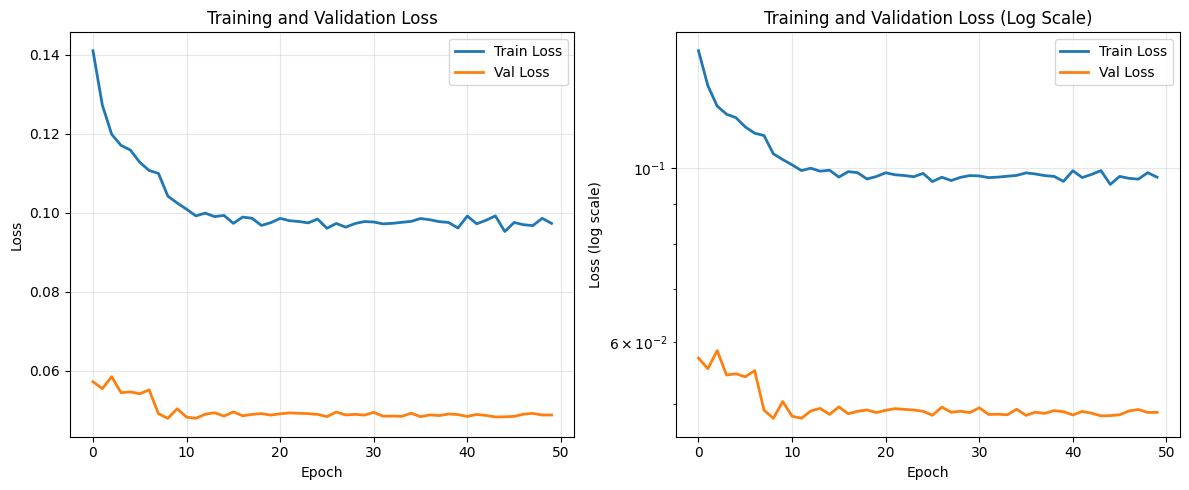

✓ Training history plot saved to /home/biopsy_gregorova/hpylori_project/RCNN_imp/outputs/training_history.png


In [12]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Val Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Val Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss (log scale)')
plt.title('Training and Validation Loss (Log Scale)')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Training history plot saved to {OUTPUT_DIR / 'training_history.png'}")

## 12. Evaluation Functions

In [13]:
def calculate_iou(box1, box2):
    """
    Calculate IoU between two boxes
    Boxes format: [x_min, y_min, x_max, y_max]
    """
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    
    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    
    union = area1 + area2 - intersection
    
    return intersection / union if union > 0 else 0


def calculate_diou(box1, box2):
    """
    Calculate DIoU (Distance IoU) between two boxes
    Boxes format: [x_min, y_min, x_max, y_max]
    """
    iou = calculate_iou(box1, box2)
    
    # Calculate center points
    c1_x = (box1[0] + box1[2]) / 2
    c1_y = (box1[1] + box1[3]) / 2
    c2_x = (box2[0] + box2[2]) / 2
    c2_y = (box2[1] + box2[3]) / 2
    
    # Distance between centers
    center_distance = ((c1_x - c2_x) ** 2 + (c1_y - c2_y) ** 2) ** 0.5
    
    # Diagonal of smallest enclosing box
    enclose_x1 = min(box1[0], box2[0])
    enclose_y1 = min(box1[1], box2[1])
    enclose_x2 = max(box1[2], box2[2])
    enclose_y2 = max(box1[3], box2[3])
    
    diagonal = ((enclose_x2 - enclose_x1) ** 2 + (enclose_y2 - enclose_y1) ** 2) ** 0.5
    
    # DIoU
    diou = iou - (center_distance ** 2) / (diagonal ** 2 + 1e-7)
    
    return diou


@torch.no_grad()
def evaluate_model(model, data_loader, device, conf_threshold=0.5, iou_threshold=0.15):
    """
    Evaluate model and calculate metrics
    """
    model.eval()
    
    all_predictions = []
    all_ground_truths = []
    
    for images, targets in tqdm(data_loader, desc="Evaluating"):
        images = [image.to(device) for image in images]
        
        # Get predictions
        predictions = model(images)
        
        # Process each image
        for pred, target in zip(predictions, targets):
            # Filter predictions by confidence
            keep = pred['scores'] > conf_threshold
            pred_boxes = pred['boxes'][keep].cpu().numpy()
            pred_scores = pred['scores'][keep].cpu().numpy()
            
            # Get ground truth boxes
            gt_boxes = target['boxes'].cpu().numpy()
            
            all_predictions.append({
                'boxes': pred_boxes,
                'scores': pred_scores
            })
            
            all_ground_truths.append({
                'boxes': gt_boxes
            })
    
    # Calculate metrics using DIoU threshold
    true_positives = 0
    false_positives = 0
    false_negatives = 0
    
    for pred, gt in zip(all_predictions, all_ground_truths):
        pred_boxes = pred['boxes']
        gt_boxes = gt['boxes']
        
        if len(gt_boxes) == 0:
            # No ground truth, all predictions are false positives
            false_positives += len(pred_boxes)
        elif len(pred_boxes) == 0:
            # No predictions, all ground truths are false negatives
            false_negatives += len(gt_boxes)
        else:
            # Match predictions to ground truths
            matched_gt = set()
            
            for pred_box in pred_boxes:
                best_diou = -1
                best_gt_idx = -1
                
                for gt_idx, gt_box in enumerate(gt_boxes):
                    if gt_idx in matched_gt:
                        continue
                    
                    diou = calculate_diou(pred_box, gt_box)
                    
                    if diou > best_diou:
                        best_diou = diou
                        best_gt_idx = gt_idx
                
                if best_diou >= iou_threshold:
                    true_positives += 1
                    matched_gt.add(best_gt_idx)
                else:
                    false_positives += 1
            
            # Unmatched ground truths are false negatives
            false_negatives += len(gt_boxes) - len(matched_gt)
    
    # Calculate metrics
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    return {
        'precision': precision,
        'recall': recall,
        'f1_score': f1_score,
        'true_positives': true_positives,
        'false_positives': false_positives,
        'false_negatives': false_negatives
    }

print("✓ Evaluation functions defined")

✓ Evaluation functions defined


## 13. Test Set Evaluation

In [14]:
# Load best model
checkpoint = torch.load(OUTPUT_DIR / 'best_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])
print(f"✓ Loaded best model from epoch {checkpoint['epoch']}")

# Evaluate on test set
print("\nEvaluating on test set...")
test_metrics = evaluate_model(
    model,
    test_loader,
    device,
    conf_threshold=CONFIG['conf_threshold'],
    iou_threshold=0.15  # DIoU threshold as per paper
)

print("\n" + "="*70)
print("TEST SET EVALUATION (DIoU ≥ 0.15)")
print("="*70)
print(f"Precision:        {test_metrics['precision']:.2%}")
print(f"Recall:           {test_metrics['recall']:.2%}")
print(f"F1 Score:         {test_metrics['f1_score']:.2%}")
print(f"\nTrue Positives:   {test_metrics['true_positives']}")
print(f"False Positives:  {test_metrics['false_positives']}")
print(f"False Negatives:  {test_metrics['false_negatives']}")
print("="*70)

# Save metrics
with open(OUTPUT_DIR / 'test_metrics.json', 'w') as f:
    json.dump(test_metrics, f, indent=2)

print(f"\n✓ Test metrics saved to {OUTPUT_DIR / 'test_metrics.json'}")

✓ Loaded best model from epoch 9

Evaluating on test set...


Evaluating: 100%|███████████████████████████████| 98/98 [00:12<00:00,  8.14it/s]


TEST SET EVALUATION (DIoU ≥ 0.15)
Precision:        31.76%
Recall:           45.00%
F1 Score:         37.24%

True Positives:   27
False Positives:  58
False Negatives:  33

✓ Test metrics saved to /home/biopsy_gregorova/hpylori_project/RCNN_imp/outputs/test_metrics.json


## 14. Visualize Predictions

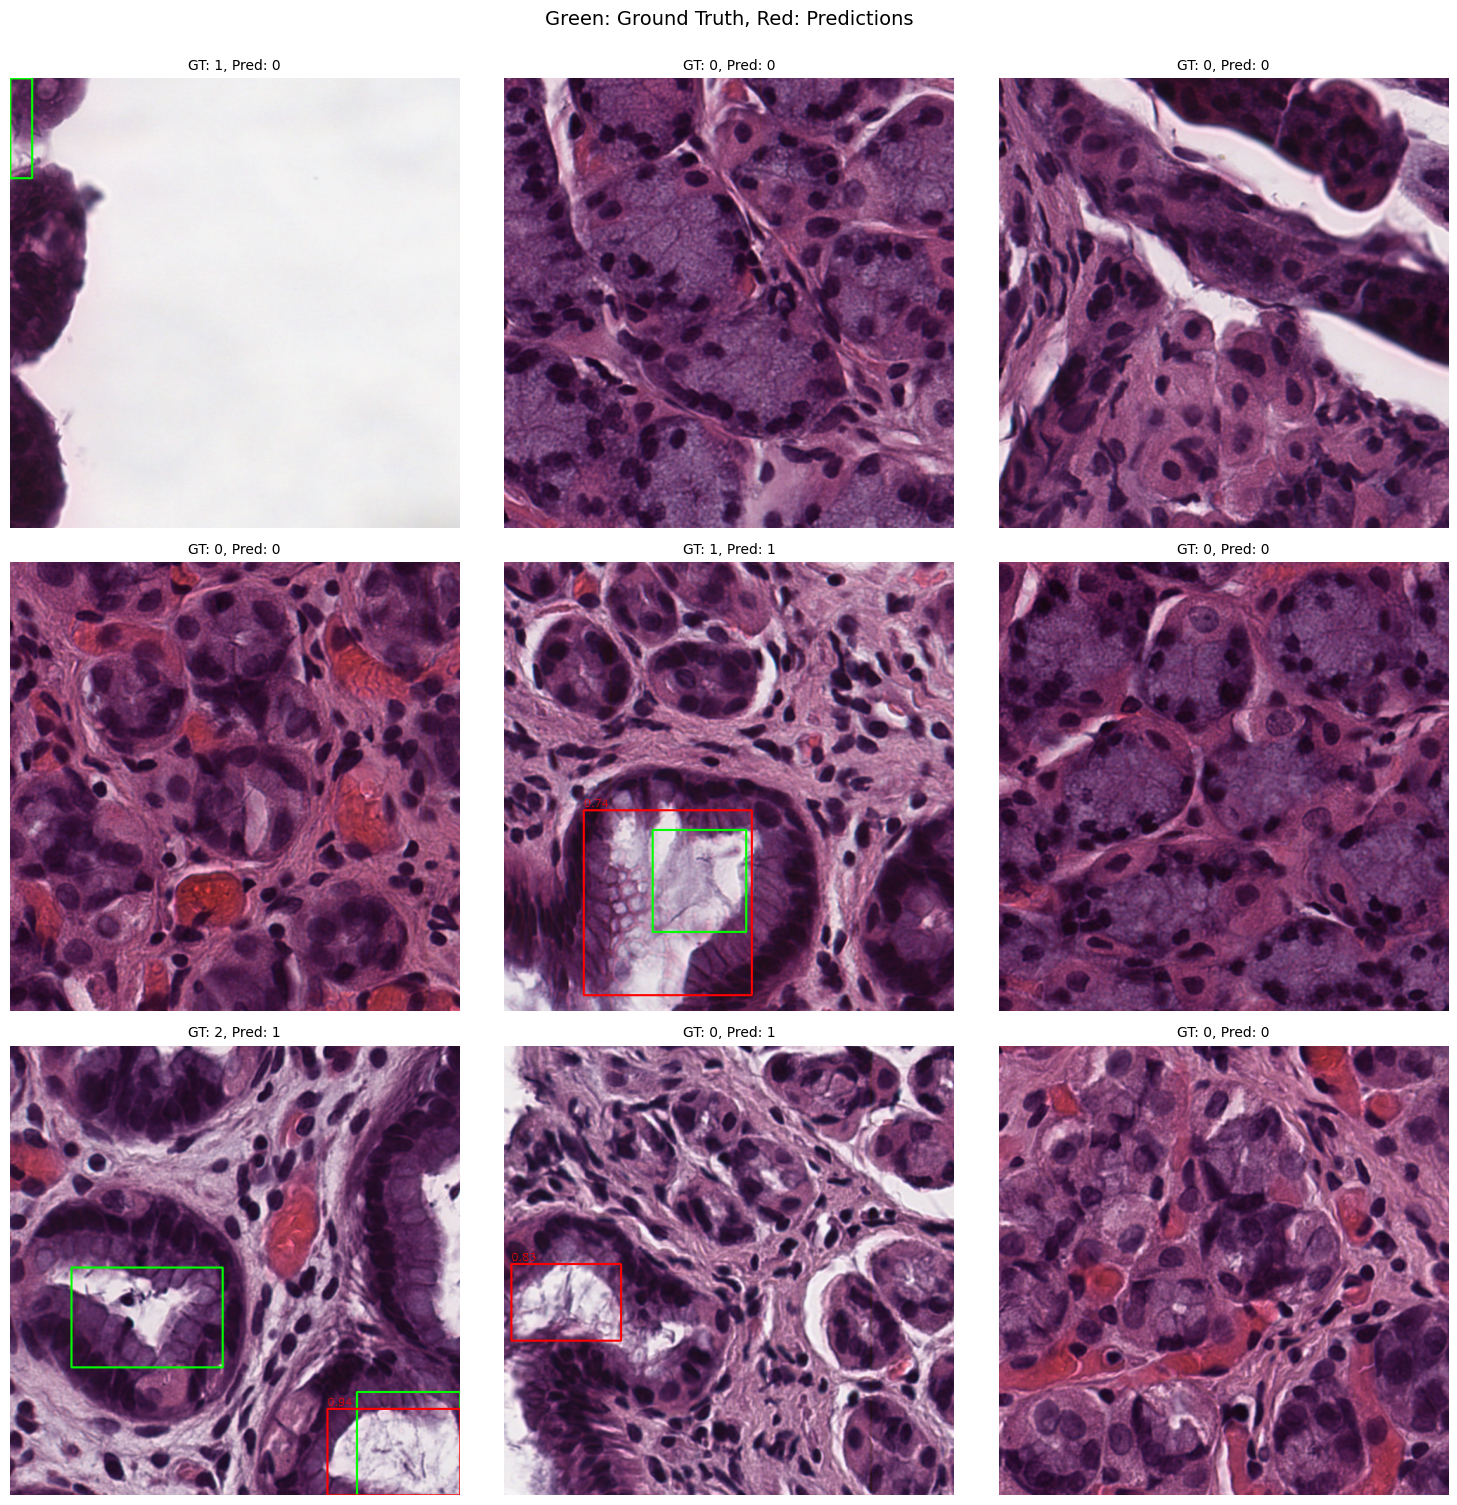

✓ Predictions visualization saved to /home/biopsy_gregorova/hpylori_project/RCNN_imp/outputs/test_predictions.png


In [15]:
@torch.no_grad()
def visualize_predictions(model, dataset, device, num_samples=9, conf_threshold=0.5):
    """
    Visualize predictions on random samples
    """
    model.eval()
    
    # Select random samples
    indices = random.sample(range(len(dataset)), min(num_samples, len(dataset)))
    
    cols = 3
    rows = (len(indices) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
    axes = axes.flatten() if rows > 1 else [axes]
    
    for idx, sample_idx in enumerate(indices):
        image, target = dataset[sample_idx]
        
        # Get prediction
        prediction = model([image.to(device)])[0]
        
        # Filter by confidence
        keep = prediction['scores'] > conf_threshold
        pred_boxes = prediction['boxes'][keep].cpu().numpy()
        pred_scores = prediction['scores'][keep].cpu().numpy()
        
        # Get ground truth
        gt_boxes = target['boxes'].cpu().numpy()
        
        # Denormalize image for visualization
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img_denorm = image * std + mean
        img_np = img_denorm.permute(1, 2, 0).cpu().numpy()
        img_np = np.clip(img_np * 255, 0, 255).astype(np.uint8)
        img_np = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
        
        # Draw ground truth boxes (green)
        for box in gt_boxes:
            cv2.rectangle(
                img_np,
                (int(box[0]), int(box[1])),
                (int(box[2]), int(box[3])),
                (0, 255, 0),  # Green
                2
            )
        
        # Draw predicted boxes (red)
        for box, score in zip(pred_boxes, pred_scores):
            cv2.rectangle(
                img_np,
                (int(box[0]), int(box[1])),
                (int(box[2]), int(box[3])),
                (0, 0, 255),  # Red
                2
            )
            # Add confidence score
            cv2.putText(
                img_np,
                f"{score:.2f}",
                (int(box[0]), int(box[1]) - 5),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (0, 0, 255),
                1
            )
        
        img_np = cv2.cvtColor(img_np, cv2.COLOR_BGR2RGB)
        
        axes[idx].imshow(img_np)
        axes[idx].set_title(
            f"GT: {len(gt_boxes)}, Pred: {len(pred_boxes)}",
            fontsize=10
        )
        axes[idx].axis('off')
    
    # Hide empty subplots
    for idx in range(len(indices), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle("Green: Ground Truth, Red: Predictions", fontsize=14, y=1.0)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'test_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"✓ Predictions visualization saved to {OUTPUT_DIR / 'test_predictions.png'}")

# Visualize predictions on test set
visualize_predictions(
    model,
    test_dataset,
    device,
    num_samples=9,
    conf_threshold=CONFIG['conf_threshold']
)

## 15. Summary Report

In [16]:
print("\n" + "="*70)
print("FASTER R-CNN TRAINING SUMMARY")
print("="*70)

print(f"\nDataset Statistics:")
print(f"  Total patches: {len(dataset_info)}")
print(f"  Positive patches: {num_positive}")
print(f"  Negative patches: {num_negative}")
print(f"  Train samples: {len(train_data)}")
print(f"  Val samples: {len(val_data)}")
print(f"  Test samples: {len(test_data)}")

print(f"\nTraining Configuration:")
print(f"  Model: Faster R-CNN with ResNet-50 FPN")
print(f"  Input size: {CONFIG['img_size']}x{CONFIG['img_size']}")
print(f"  Batch size: {CONFIG['batch_size']}")
print(f"  Epochs: {CONFIG['num_epochs']}")
print(f"  Learning rate: {CONFIG['learning_rate']}")
print(f"  Positive oversampling: {CONFIG['positive_oversampling']} (factor: {CONFIG['oversampling_factor']})")

print(f"\nModel Performance (Test Set, DIoU≥0.15):")
print(f"  Precision: {test_metrics['precision']:.2%}")
print(f"  Recall: {test_metrics['recall']:.2%}")
print(f"  F1 Score: {test_metrics['f1_score']:.2%}")

print(f"\nModel Artifacts:")
print(f"  Best model: {OUTPUT_DIR / 'best_model.pth'}")
print(f"  Training plots: {OUTPUT_DIR / 'training_history.png'}")
print(f"  Test predictions: {OUTPUT_DIR / 'test_predictions.png'}")
print(f"  TensorBoard logs: {OUTPUT_DIR / 'tensorboard'}")

print(f"\nCompare with YOLO Results:")
print(f"  YOLO Precision: 90.32%")
print(f"  YOLO Recall: 46.67%")
print(f"  YOLO F1: 61.54%")

print("="*70)

# Save summary to file
summary = {
    'dataset': {
        'total_patches': len(dataset_info),
        'positive_patches': num_positive,
        'negative_patches': num_negative,
        'train_samples': len(train_data),
        'val_samples': len(val_data),
        'test_samples': len(test_data)
    },
    'config': CONFIG,
    'test_performance': test_metrics,
    'training': {
        'best_epoch': checkpoint['epoch'],
        'best_val_loss': checkpoint['val_loss'],
        'final_train_loss': checkpoint['train_loss']
    }
}

with open(OUTPUT_DIR / 'training_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(f"\n✓ Training summary saved to {OUTPUT_DIR / 'training_summary.json'}")


FASTER R-CNN TRAINING SUMMARY

Dataset Statistics:
  Total patches: 2602
  Positive patches: 310
  Negative patches: 2292
  Train samples: 1820
  Val samples: 391
  Test samples: 391

Training Configuration:
  Model: Faster R-CNN with ResNet-50 FPN
  Input size: 640x640
  Batch size: 4
  Epochs: 50
  Learning rate: 0.0001
  Positive oversampling: True (factor: 3)

Model Performance (Test Set, DIoU≥0.15):
  Precision: 31.76%
  Recall: 45.00%
  F1 Score: 37.24%

Model Artifacts:
  Best model: /home/biopsy_gregorova/hpylori_project/RCNN_imp/outputs/best_model.pth
  Training plots: /home/biopsy_gregorova/hpylori_project/RCNN_imp/outputs/training_history.png
  Test predictions: /home/biopsy_gregorova/hpylori_project/RCNN_imp/outputs/test_predictions.png
  TensorBoard logs: /home/biopsy_gregorova/hpylori_project/RCNN_imp/outputs/tensorboard

Compare with YOLO Results:
  YOLO Precision: 90.32%
  YOLO Recall: 46.67%
  YOLO F1: 61.54%

✓ Training summary saved to /home/biopsy_gregorova/hpylori